In [29]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

https://www.kaggle.com/datasets/mathurinache/sleep-dataset

Данные из StatLib (ftp stat.cmu.edu/datasets)

Данные, на основании которых были сделаны выводы в статье Эллисона Т. и Чикетти Д. «Сон у млекопитающих: экологические и конституциональные корреляты» (1976), Science, 12 ноября, том 12, № 1, с. 194, стр. 732-734. Включает массу мозга и тела, продолжительность жизни, время беременности, время сна,
и индексы хищничества и опасности для 62 млекопитающих.

Переменные ниже (слева направо) для набора данных по млекопитающим:

вид животного

масса тела в кг

вес мозга в г

медленный сон («без сновидений») (ч/день)

парадоксальный («сновидческий») сон (ч/день)

общий сон (ч/день) (сумма медленноволнового и парадоксального сна)

максимальная продолжительность жизни (лет)
срок беременности (дни)

индекс хищничества (1-5) 1 = минимум (наименьшая вероятность стать объектом охоты) 5 = максимум (наибольшая вероятность стать жертвой)

индекс воздействия во время сна (1-5) 1 = наименее подверженное воздействию (например, животное спит в хорошо защищенном логове) 5 = наиболее подверженное воздействию

общий индекс опасности (1-
5) (на основании двух вышеуказанных показателей и другой информации) 1 = наименьшая опасность (от других животных) 5 = наибольшая опасность (от других животных)

# Предобработка

In [30]:
df = pd.read_csv('data/dataset_2191_sleep.csv')
df.head()

,body_weight,brain_weight,max_life_span,gestation_time,predation_index,sleep_exposure_index,danger_index,total_sleep
0,6654.000,5712.0,38.6,645,3,5,3,3.3
1,1.000,6.6,4.5,42,3,1,3,8.3
2,3.385,44.5,14,60,1,1,1,12.5
3,0.920,5.7,?,25,5,2,3,16.5
4,2547.000,4603.0,69,624,3,5,4,3.9


In [31]:
df['danger_index'].value_counts()

danger_index
1    19
2    14
3    10
5     9
4     8
Name: count, dtype: int64

## Обрабатываем некорректные значения

In [32]:
def none_if_not_float(val): 
    try: 
        return float(val)
    except:
        return None

In [33]:
for col in df.columns: 
    df[col] = df[col].apply(none_if_not_float)

In [34]:
df.isna().sum()

body_weight             0
brain_weight            0
max_life_span           4
gestation_time          4
predation_index         0
sleep_exposure_index    0
danger_index            0
total_sleep             4
dtype: int64

In [35]:
for col in df.columns: 
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

In [36]:
for col in ['predation_index', 'sleep_exposure_index', 'danger_index']: 
    df[col] = df[col].astype(np.int16)

In [37]:
for col in ['body_weight', 'brain_weight', 'max_life_span', 
            'gestation_time', 'total_sleep']: 
    df[col] = df[col].astype(np.float16)

In [38]:
for col in df.columns: 
    df[col] = df[col].fillna(np.median(df[col]))

## Корреляции

[]

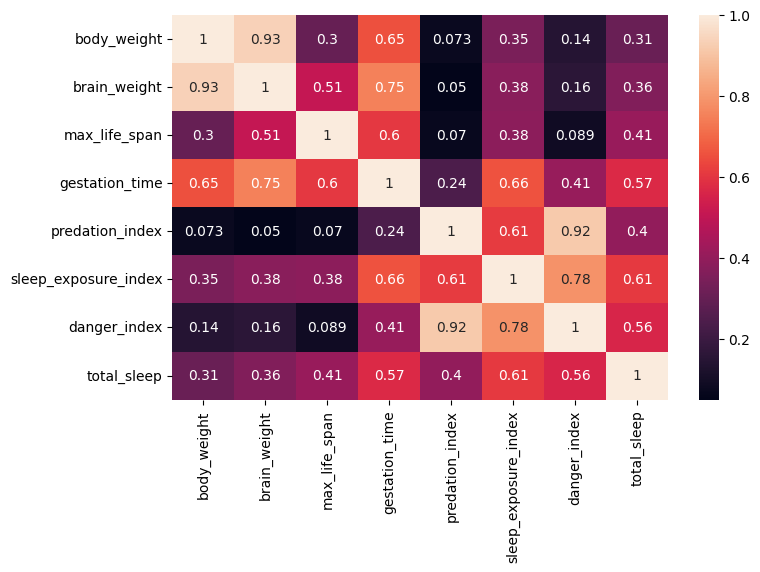

In [39]:
plt.figure(figsize=(8, 5))
sns.heatmap(np.abs(df.corr()), annot=True)
plt.plot()

In [40]:
df.drop(['brain_weight', 'predation_index'], axis=1, inplace=True)

# Обучения без обработки экстремального случая

In [41]:
target = 'danger_index'
y = df[target]
X = df.drop([target], axis=1)
column_names = X.columns

In [14]:
df[target].value_counts().sort_index()

danger_index
1    19
2    14
3    10
4     8
5     9
Name: count, dtype: int64

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


SEED = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=SEED
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)

X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [16]:
from sklearn.tree import DecisionTreeClassifier as Model
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix


model = Model(max_depth=5, random_state=SEED)
model.fit(X_train_scaled, y_train)

# Метрики на тренировочных данных
y_pred = model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=True)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=True)

print(f"Test accuracy: {acc:.6f}")
print(f"Test precision: {prec:.6f}")
print(f"Test recall: {recall:.6f}")

Test accuracy: 0.277778
Test precision: 0.569444
Test recall: 0.277778


In [17]:
def plot_and_save_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)

    labels = list(df[target].value_counts().sort_index().index)
    
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels,
                yticklabels=labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    
    plt.plot()

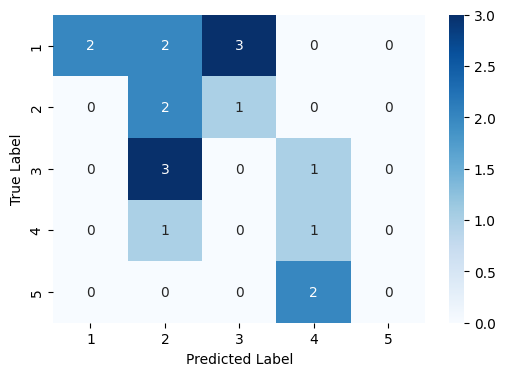

In [18]:
plot_and_save_confusion_matrix(y_test, y_pred)

# Решение экстремальной задачи

In [19]:
import warnings
warnings.filterwarnings('ignore')

In [20]:
from imblearn.over_sampling import SMOTE

y = df[target]
X = df.drop([target], axis=1)

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Применяем SMOTE для балансировки классов
smote = SMOTE(random_state=SEED)
X, y = smote.fit_resample(X_scaled, y)

df = pd.concat([pd.DataFrame(X), pd.DataFrame({target: y})], axis=1)

In [21]:
from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer

# Генерируйте данные отдельно для каждого класса
synthetic_dfs = []

for class_value in df[target].unique():
    # Выбираем данные только этого класса
    class_data = df[df[target] == class_value]
    
    if len(class_data) > 10:  # минимальное количество для обучения
        # Создаем метаданные для подмножества
        class_metadata = SingleTableMetadata()
        class_metadata.detect_from_dataframe(class_data)
        
        # Обучаем синтезатор на классе
        synthesizer = GaussianCopulaSynthesizer(class_metadata)
        synthesizer.fit(class_data)
        
        # Генерируем пропорционально
        samples_needed = max(0, len(df)//len(df[target].unique()) - len(class_data))
        if samples_needed > 0:
            synthetic_class = synthesizer.sample(num_rows=samples_needed)
            synthetic_dfs.append(synthetic_class)
    
# Добавляем оригинальные данные
synthetic_dfs.append(df)
df = pd.concat(synthetic_dfs, ignore_index=True)

In [22]:
len(df)

95

In [23]:
y = df[target]
X = df.drop([target], axis=1)

# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=SEED,
    stratify=y
)

# Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [2, 3, 4],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [2, 4],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=2,
    scoring='f1_weighted',
    n_jobs=-1, 
    verbose=1,
    refit=True
)

grid_search.fit(X_train_scaled, y_train)

print(f"\nЛучшие параметры: {grid_search.best_params_}")
print(f"Лучшая точность: {grid_search.best_score_:.6f}")

model = grid_search.best_estimator_

Fitting 2 folds for each of 24 candidates, totalling 48 fits

Лучшие параметры: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2}
Лучшая точность: 0.591883


In [25]:
# Оценка на тестовых данных
y_pred_test = model.predict(X_test_scaled)
acc_test = accuracy_score(y_test, y_pred_test)
prec_test = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
recall_test = recall_score(y_test, y_pred_test, average='weighted', zero_division=0)

print(f"\nTest accuracy: {acc_test:.6f}")
print(f"Test precision: {prec_test:.6f}")
print(f"Test recall: {recall_test:.6f}")


Test accuracy: 0.586207
Test precision: 0.597701
Test recall: 0.586207


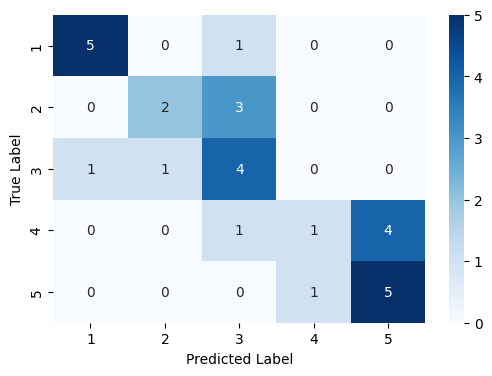

In [26]:
plot_and_save_confusion_matrix(y_test, y_pred_test)

In [42]:
from sklearn.tree import export_text

# Получаем текстовое представление
tree_rules = export_text(
    model,
    feature_names=list(column_names)
)
print("Правила дерева:")
print(tree_rules)

Правила дерева:
|--- sleep_exposure_index <= 1.29
|   |--- sleep_exposure_index <= -0.36
|   |   |--- body_weight <= -0.21
|   |   |   |--- gestation_time <= -0.72
|   |   |   |   |--- class: 3
|   |   |   |--- gestation_time >  -0.72
|   |   |   |   |--- class: 2
|   |   |--- body_weight >  -0.21
|   |   |   |--- sleep_exposure_index <= -0.68
|   |   |   |   |--- class: 1
|   |   |   |--- sleep_exposure_index >  -0.68
|   |   |   |   |--- class: 1
|   |--- sleep_exposure_index >  -0.36
|   |   |--- max_life_span <= 0.56
|   |   |   |--- class: 4
|   |   |--- max_life_span >  0.56
|   |   |   |--- class: 1
|--- sleep_exposure_index >  1.29
|   |--- gestation_time <= 2.16
|   |   |--- total_sleep <= -0.44
|   |   |   |--- class: 5
|   |   |--- total_sleep >  -0.44
|   |   |   |--- total_sleep <= -0.02
|   |   |   |   |--- class: 4
|   |   |   |--- total_sleep >  -0.02
|   |   |   |   |--- class: 5
|   |--- gestation_time >  2.16
|   |   |--- class: 3



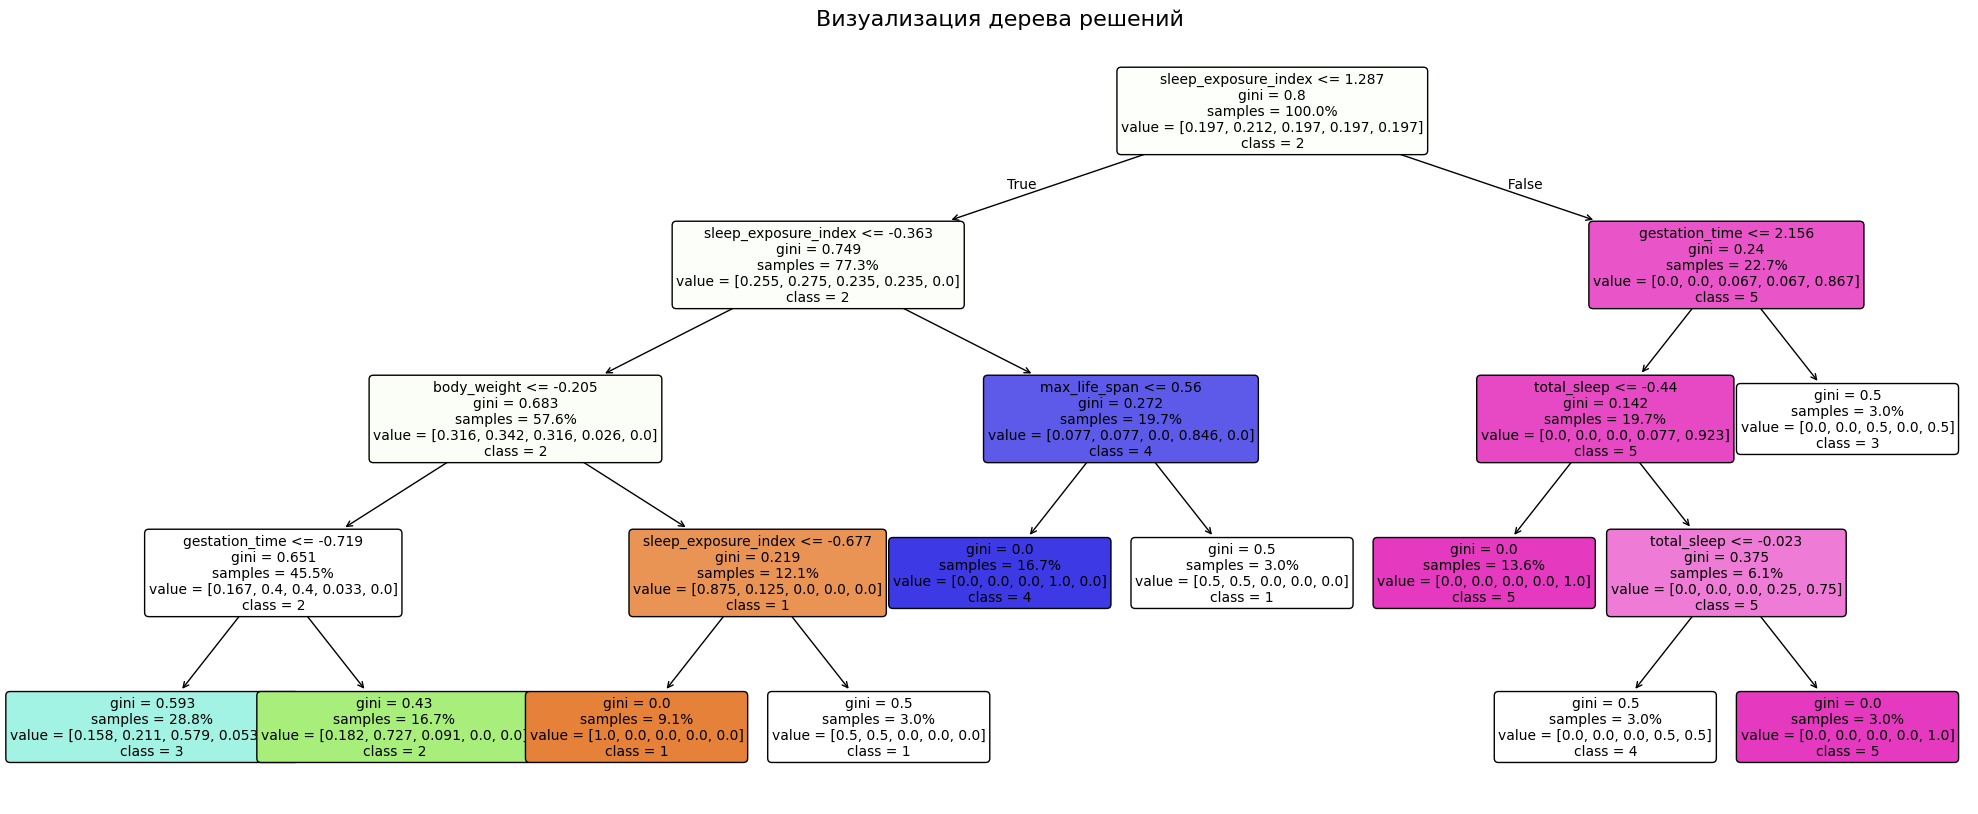

In [46]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(25, 10))
plot_tree(
    model,
    feature_names=column_names.tolist(),
    class_names=[str(i) for i in sorted(y.unique())],
    filled=True,
    rounded=True,
    fontsize=10,
    proportion=True
)
plt.title("Визуализация дерева решений", fontsize=16)
plt.show()